In [17]:
##import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
#load dataset
path = "C:/Users/Admin/Documents/ASSIGNMENTS/50_Startups.csv"
data = pd.read_csv(path)
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
data.shape

(50, 5)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [6]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [7]:
data.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

<Axes: >

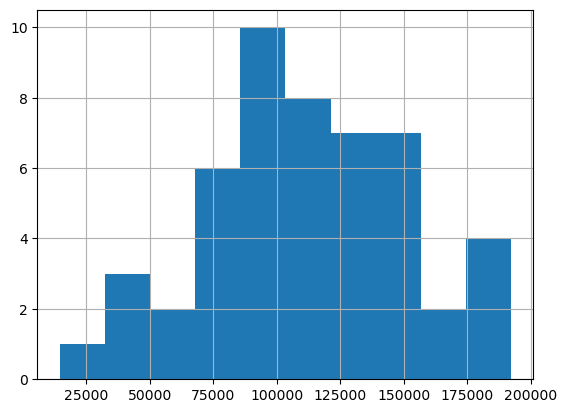

In [27]:
##EDA
data['Profit'].hist()

In [28]:
# Observation:
#Profit values are reasonably distributed across the dataset.
#The distribution appears fairly normal with no extreme skewness.
#Most values lie in the mid-range, indicating balanced data.
#Since the distribution is not highly skewed, transformation may not be strictly required.
#However, transformations will still be tested for comparison.

In [29]:
data.State.unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [30]:
##convert categorical data
df = pd.get_dummies(data,columns= ['State'],drop_first = True)
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [31]:
## X and y
X = df.drop(['Profit'] ,axis = 1)
y = df['Profit']

In [32]:
X.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False


In [33]:
##splitting of data
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size =0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((40, 5), (40,), (10, 5), (10,))

In [34]:
##load model
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
##prediction
y_pred = model.predict(X_test)
y_pred

array([127431.24898633,  83684.9760399 ,  99629.0105373 ,  47588.36470994,
       130085.40993359,  49123.07308284, 110765.3011688 , 102200.26891867,
        98988.23660304, 115594.18840731])

In [38]:
##Evaluate
print('r2 Score :', r2_score(y_test,y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,y_pred)))

r2 Score : 0.9179169317955789
RMSE: 8152.9269600946345


In [39]:
# The Linear Regression model achieved an R2 score of 0.92,
# indicating strong predictive performance.
# The RMSE is approximately 8152, meaning the model's predictions
# are on average off by around 8000 units of profit.
# Considering the profit range, this error is acceptable.
# R&D Spend shows strong influence on Profit,
# which contributes to the high model accuracy.

In [43]:
##log tranformation
y_log = np.log1p(y)
X_train,X_test,y_train,y_test = train_test_split(X,y_log, test_size= 0.2 , random_state = 42)
model.fit(X_train,y_train)
y_log_pred = model.predict(X_test)
y_log_pred

array([11.61035897, 11.20368731, 11.44050752, 10.91842219, 11.73232335,
       10.97248667, 11.5367442 , 11.35473999, 11.32518613, 11.57422434])

In [45]:
##Evaluate
print('r2 log:', r2_score(y_test, y_log_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_log_pred)))

r2 log: 0.7013251638143767
RMSE: 0.20527405165548562


In [47]:
#sqrt transformation
y_sqrt = np.sqrt(y)
X_train,X_test,y_train,y_test = train_test_split(X,y_sqrt, test_size= 0.2 , random_state = 42)
model.fit(X_train,y_train)
y_pred_sqrt = model.predict(X_test)
y_pred_sqrt

array([345.62669469, 282.12611798, 311.43300095, 229.78394864,
       355.51241617, 237.5811681 , 326.48261569, 306.3638706 ,
       302.11319107, 332.3166106 ])

In [48]:
##Evaluate
print('r2 sqrt:', r2_score(y_test, y_pred_sqrt))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_sqrt)))

r2 sqrt: 0.8306126714233569
RMSE: 20.854193250817264


In [49]:
# Note:
# For transformed models (log and sqrt), RMSE is calculated in transformed scale.
# Hence, RMSE values are not directly comparable with the original model.
# R2 score is primarily used for comparison of model performance.

In [53]:
results = pd.DataFrame({
    "Model": ["Linear", "Log", "Sqrt"],
    "R2 Score": [0.9179,0.7013 ,0.8306 ]  # replace with your values
})

results

,Model,R2 Score
0,Linear,0.9179
1,Log,0.7013
2,Sqrt,0.8306


In [ ]:
# Comparison of models:

# Linear Regression (No Transformation):
# R2 Score: 0.92 (Best performance)

# Log Transformation:
# R2 Score: lower than original, indicating reduced performance

# Square Root Transformation:
# R2 Score: moderate, but still lower than original model

# Conclusion:
# Since the dataset is not highly skewed, transformations did not improve performance.
# Therefore, the original Linear Regression model is selected as the final model.